# Tutorial 6 — Advanced Chemical Space Analysis with PCA and t-SNE
**Author:** Himanshu Goel 

This tutorial demonstrates comprehensive chemical space visualization using dimensionality reduction techniques. 

## What we'll cover:
- Multiple molecular fingerprint types (Morgan, MACCS, RDKit)
- Dimensionality reduction comparison (PCA vs t-SNE)
- Clustering analysis in reduced dimensions
- Molecular property analysis in chemical space
- Fingerprint type comparison
- Interactive chemical space exploration

In [ ]:
# Install required packages (if needed)
# !pip install rdkit pandas numpy matplotlib seaborn scikit-learn -q

import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, rdFingerprintGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Set plotting style
plt.style.use('seaborn-v0_8' if hasattr(plt.style, 'use') else 'default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Prepare Molecular Dataset

We'll work with a diverse set of molecules from different therapeutic classes to demonstrate chemical space clustering.

In [15]:
# Comprehensive molecular dataset across therapeutic classes
molecular_dataset = {
    'NSAIDs': [
        ('Aspirin', 'CC(=O)Oc1ccccc1C(=O)O'),
        ('Ibuprofen', 'CC(C)Cc1ccc(cc1)C(C)C(=O)O'),
        ('Naproxen', 'COc1ccc2cc(C(C)C(=O)O)ccc2c1'),
        ('Diclofenac', 'OC(=O)Cc1ccccc1Nc1c(Cl)cccc1Cl'),
        ('Indomethacin', 'COc1ccc2c(c1)cc([nH]2)C(=O)c1ccc(Cl)cc1'),
    ],
    'Opioids': [
        ('Morphine', 'OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1'),
        ('Codeine', 'COc1ccc2CC3N(CCC34CCc5c4cc(OC)c(O)c5)C2=c1'),
        ('Tramadol', 'OC1(c2ccccc2)CCCCC1CN(C)C'),
        ('Oxycodone', 'O=C1CCC2(O)C3Cc4ccc(O)c5c4c2c1c5C3'),
    ],
    'Stimulants': [
        ('Caffeine', 'Cn1cnc2c1c(=O)n(C)c(=O)n2C'),
        ('Amphetamine', 'CC(N)Cc1ccccc1'),
        ('Modafinil', 'NC(=O)CS(=O)c1ccc(-c2ccccc2)cc1'),
        ('Methylphenidate', 'COC(=O)c1c(CCN(C)C)cc(OC)cc1'),
    ],
    'Antidepressants': [
        ('Fluoxetine', 'CNCCC(c1ccccc1)Oc1ccc(cc1)C(F)(F)F'),
        ('Sertraline', 'CNC1CCC(c2ccc(Cl)c(Cl)c2)c2ccccc21'),
        ('Venlafaxine', 'COc1ccc(C2(CCN(C)C)CCCCC2)cc1'),
        ('Escitalopram', 'CN(C)CCCC1(c2ccc(F)cc2)OCc2cc(C#N)ccc21'),
    ],
    'Antibiotics': [
        ('Ciprofloxacin', 'OC(=O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O'),
        ('Amoxicillin', 'CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O'),
        ('Azithromycin', 'CC(CC1OC(=O)CC1CC)C1CC(C)C(=O)C(OC2CC(CC(O2)C)N(C)C)C(C)CC(CC(OC3OC(C)CC(O)C3OC)C(C)CCC(=O)O1)OC'),
    ],
    'Antivirals': [
        ('Acyclovir', 'NC1=NC(=O)C2=C(NC=N2)N1'),
        ('Oseltamivir', 'CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@H](N)C1'),
        ('Remdesivir', 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=NN2C)OC1=CC=CC=C1'),
    ]
}

# Process molecules
molecules = []
for category, compounds in molecular_dataset.items():
    for name, smiles in compounds:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            molecules.append((name, mol, category))

print(f"Successfully loaded {len(molecules)} molecules from {len(molecular_dataset)} therapeutic classes")

# Extract metadata
names = [name for name, _, _ in molecules]
categories = [cat for _, _, cat in molecules]
unique_categories = list(set(categories))

print(f"Categories: {unique_categories}")
print(f"Molecules per category: {pd.Series(categories).value_counts().to_dict()}")

[19:11:26] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 24
[19:11:26] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 13 14 15 16 17


Successfully loaded 21 molecules from 6 therapeutic classes
Categories: ['Antivirals', 'NSAIDs', 'Antidepressants', 'Stimulants', 'Antibiotics', 'Opioids']
Molecules per category: {'NSAIDs': 5, 'Stimulants': 4, 'Antidepressants': 4, 'Antibiotics': 3, 'Antivirals': 3, 'Opioids': 2}


## 2. Molecular Fingerprint Generation

We'll generate multiple types of fingerprints to compare their effectiveness in chemical space representation.

In [ ]:
def generate_fingerprints(molecules, fp_types=['morgan', 'maccs', 'rdkit']):
    """Generate multiple types of molecular fingerprints"""
    fingerprints = {}
    
    for fp_type in fp_types:
        print(f"Generating {fp_type.upper()} fingerprints...")
        
        if fp_type == 'morgan':
            # Morgan (circular) fingerprints
            morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
            fps = [morgan_gen.GetFingerprint(mol) for _, mol, _ in molecules]
            fingerprints[fp_type] = np.array(fps)

        elif fp_type == 'maccs':
            # MACCS keys (structural keys)
            fps = [MACCSkeys.GenMACCSKeys(mol) for _, mol, _ in molecules]
            fingerprints[fp_type] = np.array(fps)
            
        elif fp_type == 'rdkit':
            # RDKit topological fingerprints
            fps = [Chem.RDKFingerprint(mol, maxPath=5, fpSize=2048)
                  for _, mol, _ in molecules]
            fingerprints[fp_type] = np.array(fps)
    
    return fingerprints

# Generate fingerprints
fp_types = ['morgan', 'maccs', 'rdkit']
fingerprints = generate_fingerprints(molecules, fp_types)

print("\nFingerprint shapes:")
for fp_type, fp_array in fingerprints.items():
    print(f"  {fp_type}: {fp_array.shape}")

Generating MORGAN fingerprints...
Generating MACCS fingerprints...
Generating RDKIT fingerprints...

Fingerprint shapes:
  morgan: (21, 2048)
  maccs: (21, 167)
  rdkit: (21, 2048)


## 3. Dimensionality Reduction Analysis

Compare PCA and t-SNE for visualizing chemical space.

PCA explained variance ratio: [0.11939039 0.10061617]
Total variance explained by 2 PCs: 22.0%


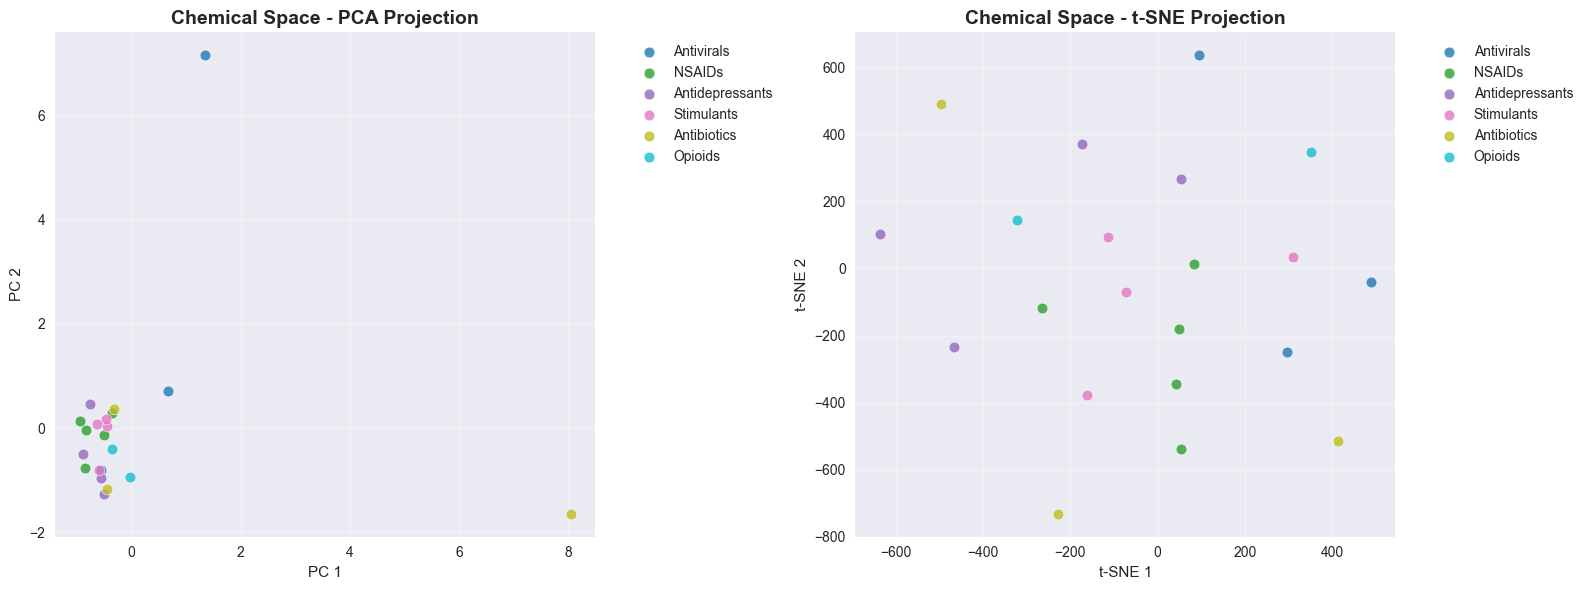

In [8]:
# Use Morgan fingerprints for main analysis
X_morgan = fingerprints['morgan']

# PCA Analysis
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_morgan)

# t-SNE Analysis
tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000, learning_rate=200.0)
X_tsne = tsne.fit_transform(X_morgan)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

# Create color mapping
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_categories)))
category_colors = dict(zip(unique_categories, colors))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
for category in unique_categories:
    mask = [c == category for c in categories]
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[category_colors[category]], label=category,
               alpha=0.8, s=60, edgecolors='white', linewidths=0.5)

ax1.set_title('Chemical Space - PCA Projection', fontsize=14, fontweight='bold')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# t-SNE plot
for category in unique_categories:
    mask = [c == category for c in categories]
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[category_colors[category]], label=category,
               alpha=0.8, s=60, edgecolors='white', linewidths=0.5)

ax2.set_title('Chemical Space - t-SNE Projection', fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chemical_space_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Clustering Analysis

Apply clustering algorithms to identify natural groupings in the chemical space.

KMEANS clustering:
  Number of clusters: 6
  Silhouette score: 0.238
DBSCAN clustering: Only 1 cluster found


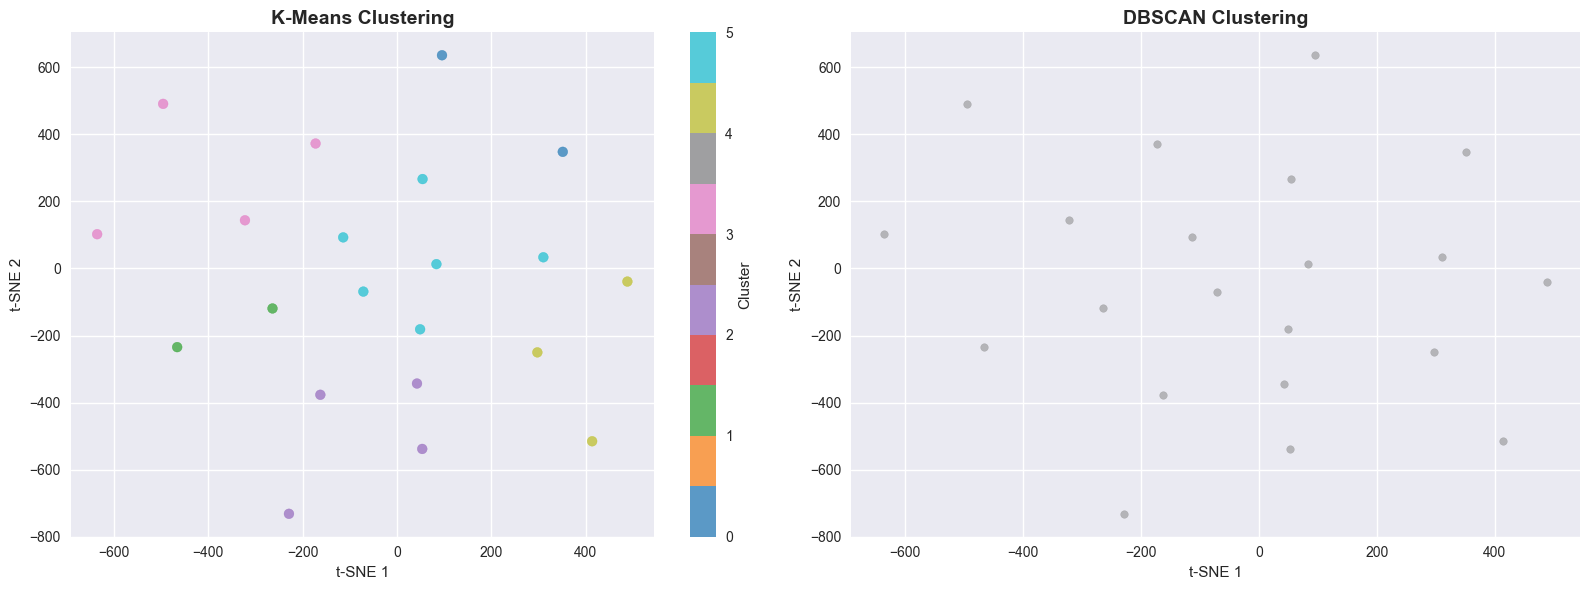

In [10]:
# Test different clustering approaches
clustering_results = {}

# K-Means clustering
kmeans = KMeans(n_clusters=len(unique_categories), random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_tsne)
clustering_results['kmeans'] = kmeans_labels

# DBSCAN clustering
dbscan = DBSCAN(eps=3.0, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_tsne)
clustering_results['dbscan'] = dbscan_labels

# Evaluate clustering quality
for method, labels in clustering_results.items():
    try:
        if len(set(labels)) > 1:  # Need at least 2 clusters for silhouette
            sil_score = silhouette_score(X_tsne, labels)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            print(f"{method.upper()} clustering:")
            print(f"  Number of clusters: {n_clusters}")
            print(f"  Silhouette score: {sil_score:.3f}")
        else:
            print(f"{method.upper()} clustering: Only 1 cluster found")
    except:
        print(f"{method.upper()} clustering: Could not evaluate")

# Visualize clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-means plot
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels,
                      cmap='tab10', alpha=0.7, s=50)
ax1.set_title('K-Means Clustering', fontsize=14, fontweight='bold')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# DBSCAN plot
unique_labels = set(dbscan_labels)
if -1 in unique_labels:  # Noise points
    # Plot noise points
    noise_mask = dbscan_labels == -1
    ax2.scatter(X_tsne[noise_mask, 0], X_tsne[noise_mask, 1],
               c='gray', alpha=0.5, s=30, label='Noise')

    # Plot clusters
    cluster_mask = dbscan_labels != -1
    if cluster_mask.any():
        scatter2 = ax2.scatter(X_tsne[cluster_mask, 0], X_tsne[cluster_mask, 1],
                              c=dbscan_labels[cluster_mask], cmap='tab10', alpha=0.7, s=50)
        plt.colorbar(scatter2, ax=ax2, label='Cluster')
else:
    scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels,
                          cmap='tab10', alpha=0.7, s=50)
    plt.colorbar(scatter2, ax=ax2, label='Cluster')

ax2.set_title('DBSCAN Clustering', fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Molecular Properties Analysis

Analyze how molecular properties correlate with chemical space positioning.

Molecular properties summary:
       molecular_weight       logp        tpsa  h_bond_donors  \
count         21.000000  21.000000   21.000000      21.000000   
mean         300.840810   2.504774   62.554762       1.333333   
std          145.885803   1.807785   45.589622       1.064581   
min          135.210000  -1.029300   12.030000       0.000000   
25%          230.263000   1.576300   36.260000       1.000000   
50%          285.730000   2.626000   49.330000       1.000000   
75%          323.392000   3.848800   74.570000       2.000000   
max          784.041000   5.459000  182.460000       4.000000   

       h_bond_acceptors  rotatable_bonds  heavy_atoms      rings  \
count         21.000000        21.000000    21.000000  21.000000   
mean           3.952381         4.142857    21.285714   2.380952   
std            3.383433         3.182542    10.090307   1.160870   
min            1.000000         0.000000    10.000000   1.000000   
25%            2.000000         2.000000    

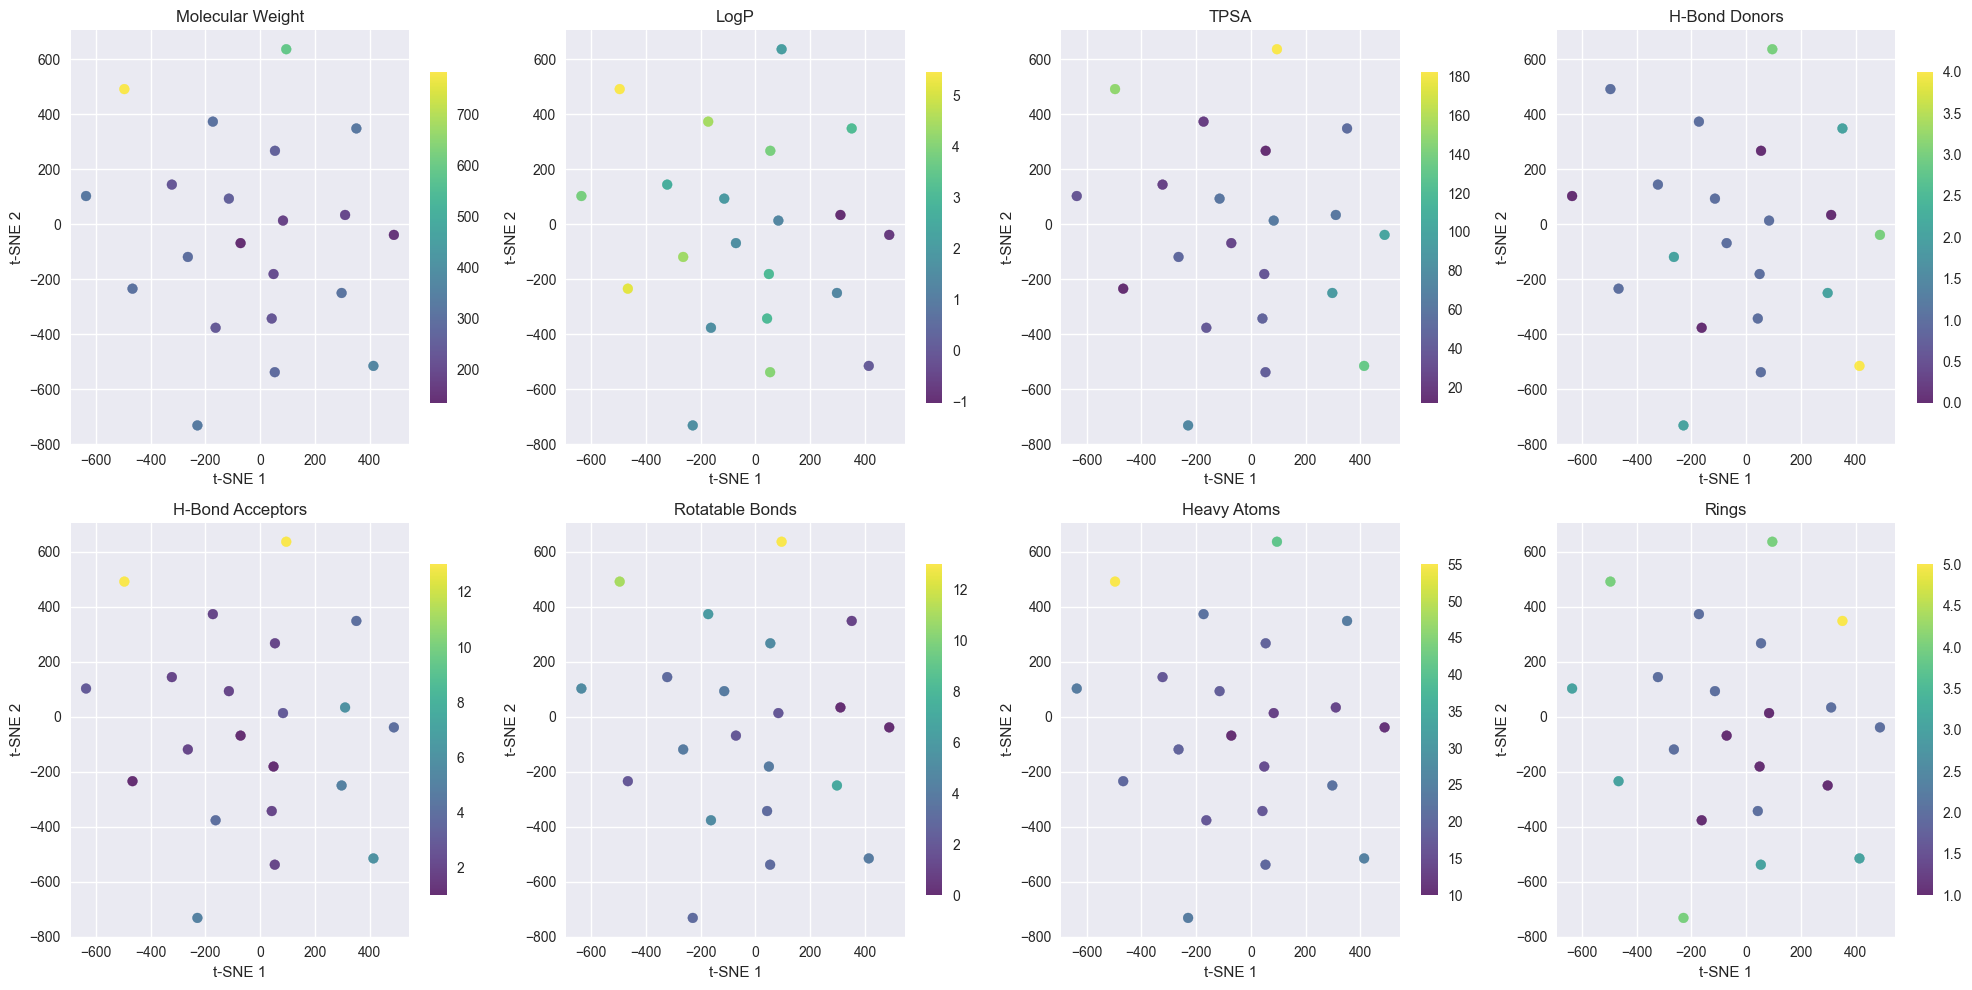

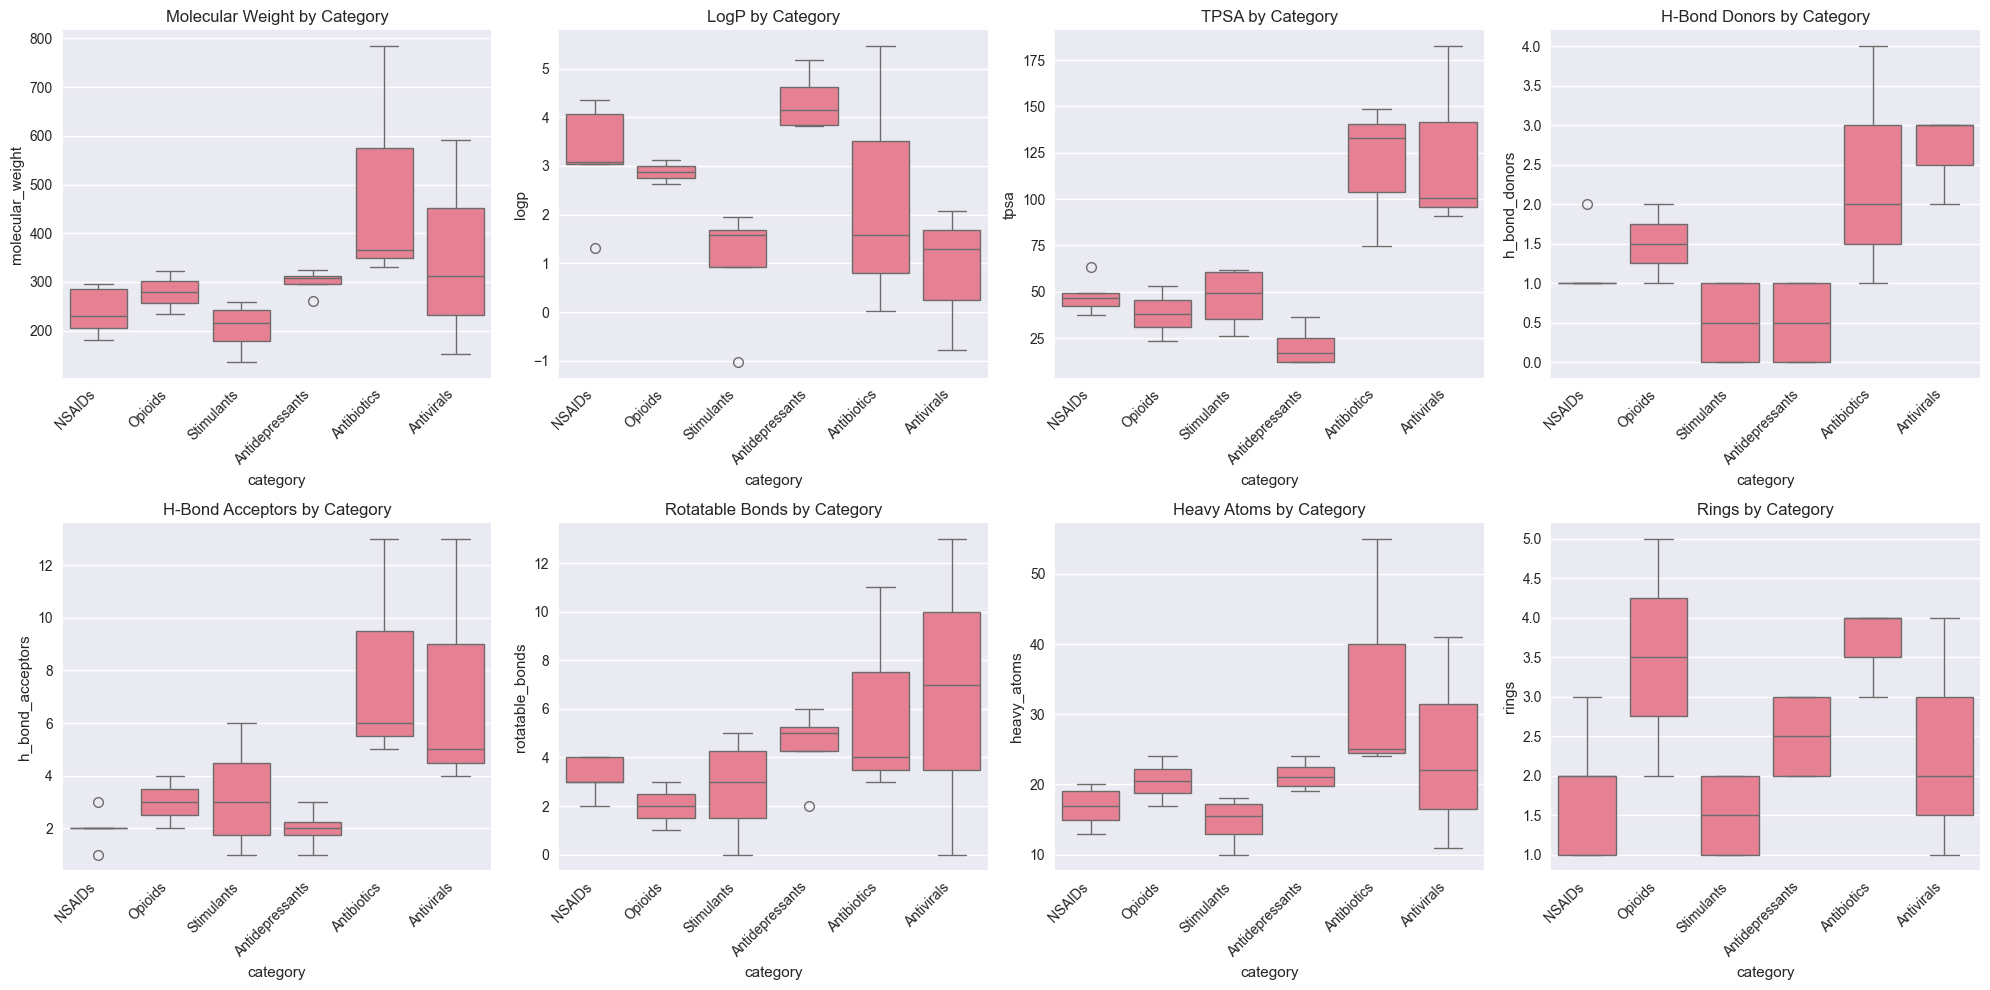

In [11]:
# Calculate molecular properties
properties = []
for name, mol, category in molecules:
    props = {
        'name': name,
        'category': category,
        'molecular_weight': Descriptors.MolWt(mol),
        'logp': Descriptors.MolLogP(mol),
        'tpsa': Descriptors.TPSA(mol),
        'h_bond_donors': Descriptors.NumHDonors(mol),
        'h_bond_acceptors': Descriptors.NumHAcceptors(mol),
        'rotatable_bonds': Descriptors.NumRotatableBonds(mol),
        'heavy_atoms': Descriptors.HeavyAtomCount(mol),
        'rings': Descriptors.RingCount(mol),
        'aromatic_rings': Descriptors.NumAromaticRings(mol)
    }
    properties.append(props)

props_df = pd.DataFrame(properties)
props_df['tsne_x'] = X_tsne[:, 0]
props_df['tsne_y'] = X_tsne[:, 1]

print("Molecular properties summary:")
print(props_df.describe())

# Property distribution plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

prop_cols = ['molecular_weight', 'logp', 'tpsa', 'h_bond_donors',
            'h_bond_acceptors', 'rotatable_bonds', 'heavy_atoms', 'rings']
prop_names = ['Molecular Weight', 'LogP', 'TPSA', 'H-Bond Donors',
             'H-Bond Acceptors', 'Rotatable Bonds', 'Heavy Atoms', 'Rings']

for i, (prop, name) in enumerate(zip(prop_cols, prop_names)):
    if i < len(axes):
        scatter = axes[i].scatter(
            props_df['tsne_x'], props_df['tsne_y'],
            c=props_df[prop], cmap='viridis', alpha=0.8, s=50
        )
        axes[i].set_title(f'{name}', fontsize=12)
        axes[i].set_xlabel('t-SNE 1')
        axes[i].set_ylabel('t-SNE 2')
        plt.colorbar(scatter, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.savefig('molecular_properties_space.png', dpi=150, bbox_inches='tight')
plt.show()

# Property distributions by category
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (prop, name) in enumerate(zip(prop_cols, prop_names)):
    if i < len(axes):
        sns.boxplot(data=props_df, x='category', y=prop, ax=axes[i])
        axes[i].set_title(f'{name} by Category', fontsize=12)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('property_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Fingerprint Type Comparison

Compare how different fingerprint types affect chemical space representation.

MORGAN: Silhouette score = -0.161
MACCS: Silhouette score = -0.216
RDKIT: Silhouette score = -0.202


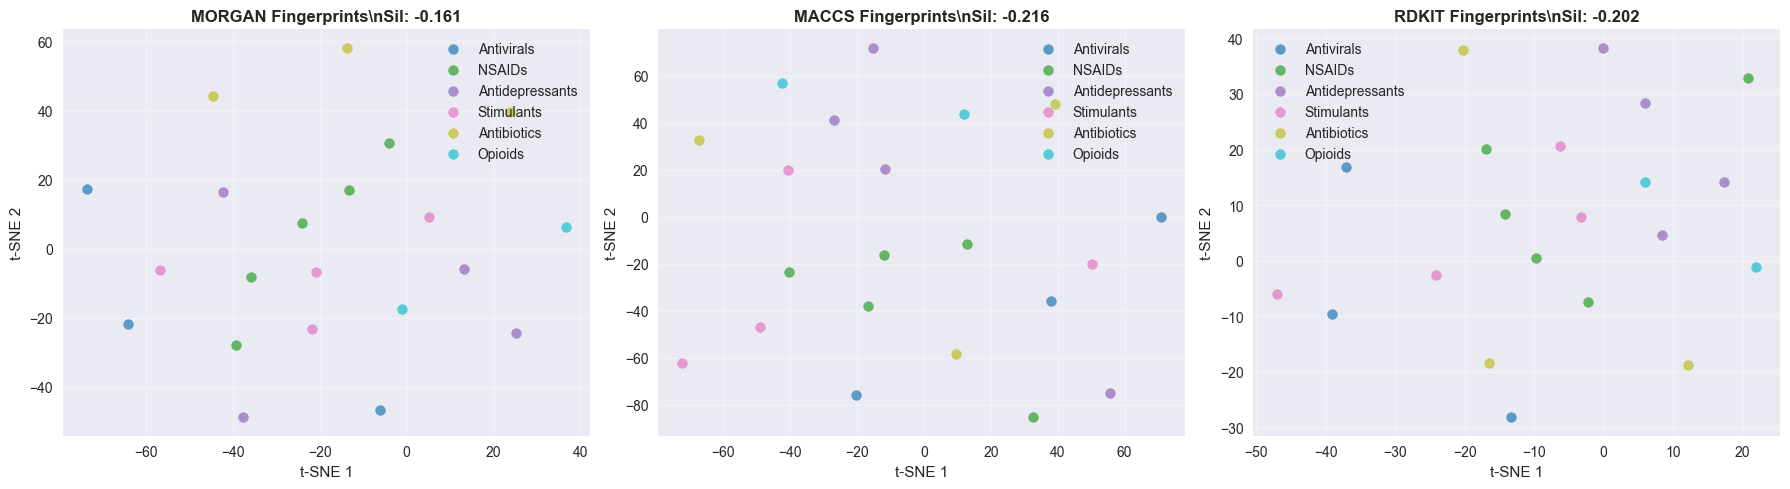

In [12]:
comparison_results = []

for fp_type in fp_types:
    X = fingerprints[fp_type]

    # Apply t-SNE for comparison
    tsne_comp = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=500)
    X_embedded = tsne_comp.fit_transform(X)

    # Evaluate clustering quality using therapeutic categories
    cat_numeric = [unique_categories.index(cat) for cat in categories]

    try:
        sil_score = silhouette_score(X_embedded, cat_numeric)
        result = {
            'fingerprint': fp_type,
            'silhouette_score': sil_score,
            'embedding': X_embedded
        }
        comparison_results.append(result)
        print(f"{fp_type.upper()}: Silhouette score = {sil_score:.3f}")
    except Exception as e:
        print(f"{fp_type.upper()}: Could not evaluate ({str(e)})")

# Visualize fingerprint comparison
if comparison_results:
    fig, axes = plt.subplots(1, len(comparison_results), figsize=(6*len(comparison_results), 5))

    if len(comparison_results) == 1:
        axes = [axes]

    for i, result in enumerate(comparison_results):
        ax = axes[i]
        embedding = result['embedding']

        for category in unique_categories:
            mask = [c == category for c in categories]
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                      c=[category_colors[category]], label=category,
                      alpha=0.7, s=50)

        ax.set_title(f'{result["fingerprint"].upper()} Fingerprints\\nSil: {result["silhouette_score"]:.3f}',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('fingerprint_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Summary and Key Findings

Let's summarize the insights from our chemical space analysis.

In [14]:
# Generate summary statistics
summary = {
    'total_molecules': len(molecules),
    'therapeutic_classes': len(unique_categories),
    'pca_variance_explained': pca.explained_variance_ratio_.sum(),
    'best_fingerprint': max(comparison_results, key=lambda x: x['silhouette_score'])['fingerprint'] if comparison_results else 'N/A'
}

print("="*50)
print("CHEMICAL SPACE ANALYSIS SUMMARY")
print("="*50)
print(f"Total molecules analyzed: {summary['total_molecules']}")
print(f"Therapeutic classes: {summary['therapeutic_classes']}")
print(f"PCA variance explained (2D): {summary['pca_variance_explained']:.1%}")
print(f"Best fingerprint type: {summary['best_fingerprint']}")

# Save results
props_df.to_csv('chemical_space_analysis_results.csv', index=False)

print("\nFiles generated:")
print("- chemical_space_pca_tsne.png")
print("- clustering_analysis.png")
print("- molecular_properties_space.png")
print("- property_distributions.png")
print("- fingerprint_comparison.png")
print("- chemical_space_analysis_results.csv")

print("\n" + "="*50)
print("TUTORIAL COMPLETED SUCCESSFULLY!")
print("="*50)
print("\nKey Insights:")
print("1. PCA provides interpretable projections but may not capture non-linear relationships")
print("2. t-SNE excels at preserving local structure and revealing clusters")
print("3. Different fingerprint types capture different aspects of molecular similarity")
print("4. Molecular properties show clear gradients across chemical space")
print("5. Therapeutic classes often form distinct clusters in reduced dimensional space")

CHEMICAL SPACE ANALYSIS SUMMARY
Total molecules analyzed: 21
Therapeutic classes: 6
PCA variance explained (2D): 22.0%
Best fingerprint type: morgan

Files generated:
- chemical_space_pca_tsne.png
- clustering_analysis.png
- molecular_properties_space.png
- property_distributions.png
- fingerprint_comparison.png
- chemical_space_analysis_results.csv

TUTORIAL COMPLETED SUCCESSFULLY!

Key Insights:
1. PCA provides interpretable projections but may not capture non-linear relationships
2. t-SNE excels at preserving local structure and revealing clusters
3. Different fingerprint types capture different aspects of molecular similarity
4. Molecular properties show clear gradients across chemical space
5. Therapeutic classes often form distinct clusters in reduced dimensional space
